# **PROJECT OVERVIEW**

The goal for this project is to predict bank churn rate from a previously done analysis.

From the analysis older people left more than the younger people.

Disengaged customers had most churn rates.

Customers from the lower credit score band between 400 and below had a 100% churn rate.

Customers from Germany has the most exits.

In [201]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #metrics used to evaluate the classification model
from sklearn.preprocessing import StandardScaler #module used to scale features

In [202]:
#loading the dataset for model training
churn_df = pd.read_csv("Bank_Churn.csv")
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



**EDA**

*   Dataset has no missing values
*   Data has no duplicate values
*   Total amount of customers exited is 2037
*   Total customers retained is 7963





In [203]:
churn_df["CreditBand"] = churn_df["CreditScore"].apply(lambda x: "low" if x <= 400 else ("medium" if x >400 and x <= 600 else "high"))
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditBand
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,high
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,high
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,medium
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,high
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,high


In [204]:
#encoding gender, geography and creditband column using one hot encoding

encoded_df = pd.get_dummies(churn_df, columns=['Gender','Geography', 'CreditBand'], dtype=int)

In [205]:
encoded_df.head()

,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain,CreditBand_high,CreditBand_low,CreditBand_medium
0,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,1,0,1,0,0,1,0,0
1,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,1,0,0,0,1,1,0,0
2,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,1,0,1,0,0,0,0,1
3,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,1,0,1,0,0,1,0,0
4,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,1,0,0,0,1,1,0,0


In [206]:
# finding numeric columns in the dataframe
numeric_df = encoded_df.select_dtypes(include = "number").drop('CustomerId', axis=1)
numeric_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain,CreditBand_high,CreditBand_low,CreditBand_medium
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,1,0,0,1,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0,0,0,1,1,0,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,1,0,0,0,0,1
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,1,0,0,1,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0,0,0,1,1,0,0


In [207]:
#converting object\string into a float
#numeric_df['Balance'] = numeric_df['Balance'].astype(float)
#numeric_df['EstimatedSalary'] = numeric_df['EstimatedSalary'].astype(float)

In [208]:
numeric_columns= numeric_df.columns.drop('Exited')
numeric_columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Gender_Female', 'Gender_Male',
       'Geography_France', 'Geography_Germany', 'Geography_Spain',
       'CreditBand_high', 'CreditBand_low', 'CreditBand_medium'],
      dtype='object')

In [209]:
#using standard scaler for scaling features for training
scaler = StandardScaler()

scaled_features = scaler.fit_transform(numeric_df[numeric_columns])

scaled_df = pd.DataFrame(
    scaled_features,
    columns=numeric_columns
) #builds dataframe for the new scaled data

In [210]:
scaled_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain,CreditBand_high,CreditBand_low,CreditBand_medium
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1.095988,-1.095988,0.997204,-0.578736,-0.573809,0.664958,-0.04363,-0.661988
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,1.095988,-1.095988,-1.002804,-0.578736,1.742740,0.664958,-0.04363,-0.661988
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1.095988,-1.095988,0.997204,-0.578736,-0.573809,-1.503855,-0.04363,1.510601
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,1.095988,-1.095988,0.997204,-0.578736,-0.573809,0.664958,-0.04363,-0.661988
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,1.095988,-1.095988,-1.002804,-0.578736,1.742740,0.664958,-0.04363,-0.661988


In [211]:
#splitting data into target and features (multivariate)
x = scaled_df[scaled_df.columns.to_list()] #creates a dataframe of features used to train the model
y = churn_df['Exited'] #target column the model is trying to predict


In [212]:
#slitting data using sklearn train_test_split
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state =42)

In [213]:
#importing modules for training
import xgboost as xgb
from xgboost import XGBClassifier

In [214]:
#Identifying scale to optimize positive class
pos_nos = sum(ytrain == 1) #counting the number of positive occurences
neg_nos = sum(ytrain == 0) #counting number of negative occurences
ratio = neg_nos/pos_nos #finds the ratio of negative occurences to positive ones
ratio #weight used to scale positive occurences

3.8661800486618003

In [215]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [ratio, ratio * 0.8, ratio * 1.2]
}

auc_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='auc', random_state=42),
    param_distributions=param_grid,
    n_iter=25,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

auc_search.fit(xtrain, ytrain)

# Best model tuned for AUC
best_xgb_model = auc_search.best_estimator_
print("Best Hyperparameters for AUC:", auc_search.best_params_)

Best Hyperparameters for AUC: {'subsample': 0.8, 'scale_pos_weight': 3.0929440389294403, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [216]:
#Initialize and train XGBoost
xgb_model = XGBClassifier(
    n_estimators=484,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=ratio*0.8,  # Crucial for your imbalanced dataset
    #early_stopping_rounds=50,  # Stops if AUC doesn't improve for 50 consecutive rounds
    random_state=42,
    eval_metric='auc'
)

In [217]:
xgb_model.fit(
    xtrain,
    ytrain
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=484,
              n_jobs=None, num_parallel_tree=None, ...)

In [218]:
# Make predictions using the trained model
preds2 = xgb_model.predict(xtest)

# **Evaluting Model**

In [219]:
xgb_ac = accuracy_score(ytest, preds2)*100
print(f'{xgb_ac:.2f}%')

83.75%


In [220]:
xgb_report = classification_report(ytest, preds2)
print(xgb_report)

              precision    recall  f1-score   support

           0       0.93      0.87      0.90      1607
           1       0.57      0.72      0.63       393

    accuracy                           0.84      2000
   macro avg       0.75      0.79      0.76      2000
weighted avg       0.86      0.84      0.84      2000



In [221]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get predicted probabilities for the positive class (churn = 1)
y_probs = xgb_model.predict_proba(xtest)[:, 1]

# Calculate exact ROC-AUC Score
auc_score = roc_auc_score(ytest, y_probs)*100
print(f"ROC-AUC Score: {auc_score:.4f}%")

ROC-AUC Score: 86.4978%


# **Assessing Feature Contributions On The Model**

In [222]:
import shap

In [223]:
# Creating the SHAP Explainer object
explainer = shap.TreeExplainer(xgb_model)

In [224]:
# Computing SHAP values for the test set
shap_values = explainer(xtest)

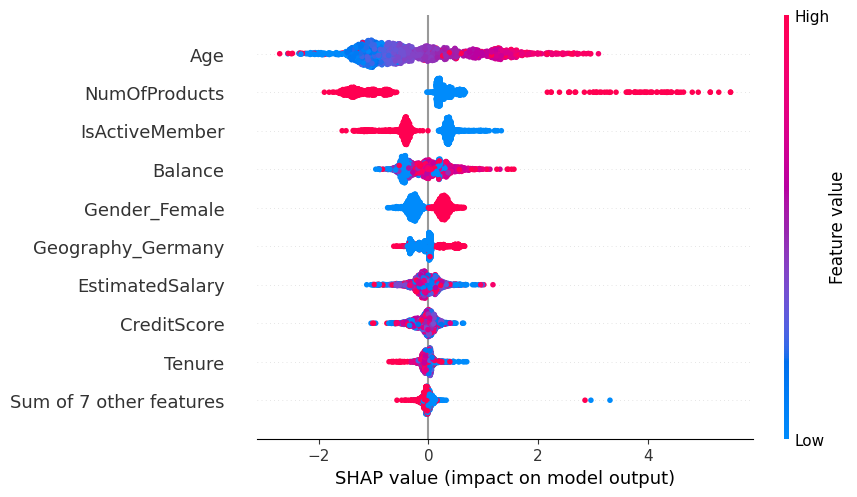

In [225]:
shap.plots.beeswarm(shap_values)


# **Exporting Model**

In [226]:
import pickle

In [227]:
with open ('churn_model.pkl', 'wb') as file:
  pickle.dump(xgb_model, file)